This is a pipeline constituting an RNN, LSTM, and Transformer which will train on the same uniformly processed dataset of historical S&P 500 data, which will be processed and prepared to be sent into the models, which will then be initially trained. Following this, they will have hyperparemeter tuning performed on them, and finally metrics and graphs will show the final results.

# 1. Universal Installs/Imports/Constants

# Install necessary libraries

In [ ]:
!pip install -q yfinance optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.2 MB/s eta 0:00:00


# Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import json
import time
from copy import deepcopy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import yfinance as yf
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Warnings, Seed, GPU Usage, and Hyperparameters

In [ ]:
# Warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# Seed Setting for Reproducability
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set to GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Hyperparameters
WINDOW_SIZE = 300
BATCH_SIZE = 32
NUM_EPOCHS = 60
INPUT_SIZE = 8

Device: cuda
GPU: Tesla T4


These steps installed, imported, and set constant variables necessary for the following pipeline.

# 2. Download and Preparation/Split/Feature Extraction of Dataset (yfinance historical S&P 500 Data)

# Download the Historical S&P 500 dataset using yfinance

source: https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html#yfinance.download

In [ ]:
# Download and view dataset

S_P_Dataset = yf.download("^GSPC", start="2000-01-01", end="2026-4-1", progress=False)

S_P_Dataset.dropna()

print(f"Dataset shape: {S_P_Dataset.shape}")
print(f"Date range: {S_P_Dataset.index[0].date()} to {S_P_Dataset.index[-1].date()}")
S_P_Dataset.tail(5)

# S_P_Dataset['Close'].tail(5)

Dataset shape: (6600, 5)
Date range: 2000-01-03 to 2026-03-31


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2026-03-25,6591.899902,6633.939941,6568.410156,6598.350098,4936720000
2026-03-26,6477.160156,6573.220215,6473.790039,6555.859863,4845560000
2026-03-27,6368.850098,6453.890137,6356.080078,6453.890137,5303490000
2026-03-30,6343.720215,6427.310059,6316.910156,6403.370117,5458640000
2026-03-31,6528.520020,6539.049805,6395.879883,6395.879883,6396100000


# Feature Engineering

RSI implementation based on Wilder (1978) smoothing via EWM — see:
https://www.investopedia.com/terms/r/rsi.asp
Using com=13 for ewm() matches Wilder's original 1/(1+14) smoothing factor

In [ ]:
# Feature engineering to generate usable and effective inputs for models to analyze and predict trends

# NOTE: Models receive 8 continuous, normalized technical features per timestep —
# NOT raw binary up/down signals. The binary 'Label' column is the prediction
# target only. Features: Return, ROC_5, ROC_10, RSI_14, MA_Spread, MACD_Hist,
# ATR_14, OBV_norm. This is consistent across all three architectures.

df = S_P_Dataset.copy()
df.columns = df.columns.droplevel(1) if isinstance(df.columns, pd.MultiIndex) else df.columns

# Daily return and Binary classification determining close as up/down (1/0 respectively).
df['Return'] = df['Close'].pct_change()
df['Label'] = (df['Return'] > 0).astype(int)

# Momentum over 5 and 10 days respectively for ROC_5 and ROC_10
df['ROC_5'] = df['Close'].pct_change(5)
df['ROC_10'] = df['Close'].pct_change(10)

# Relative Strength Index (14-day, Wilder smoothing)
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()
rs = avg_gain / (avg_loss + 1e-9)
df['RSI_14']    = 100 - (100 / (1 + rs))

# Moving Average over time (normalized)
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_Spread'] = (df['MA_10'] - df['MA_50']) / df['MA_50']

#  Moving Average Convergence Divergence (MACD) signal line spread
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
macd = ema12 - ema26
df['MACD_Hist'] = macd - macd.ewm(span=9, adjust=False).mean()

# Volatility - Average True Range (ATR) over 14 days
high_low = df['High'] - df['Low']
high_pc = (df['High'] - df['Close'].shift()).abs()
low_pc = (df['Low'] - df['Close'].shift()).abs()
tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
df['ATR_14'] = tr.rolling(14).mean()

# Volume - OBV (normalized)
obv = (np.sign(df['Return']) * df['Volume']).fillna(0).cumsum()
df['OBV_norm'] = (obv - obv.rolling(20).mean()) / (obv.rolling(20).std() + 1e-9)

# Final feature set for models to train on and learn from

FEATURES = ['Return', 'ROC_5', 'ROC_10', 'RSI_14', 'MA_Spread', 'MACD_Hist', 'ATR_14', 'OBV_norm']
df.dropna(inplace=True)

# Normalize features with z-score and rolling.
for col in FEATURES:
    roll_mean = df[col].rolling(252).mean().shift(1)
    roll_std = df[col].rolling(252).std().shift(1)
    df[col] = (df[col] - roll_mean) / (roll_std + 1e-9)

df.dropna(inplace=True)
print(f"Features shape after engineering: {df[FEATURES].shape}")
print(df[FEATURES].tail(3))

Features shape after engineering: (6299, 8)
Price         Return     ROC_5    ROC_10    RSI_14  MA_Spread  MACD_Hist  \
Date                                                                       
2026-03-27 -1.506338 -1.092569 -1.685811 -2.570327  -1.624762  -1.478904   
2026-03-30 -0.387212 -1.759067 -2.154448 -2.622600  -1.748403  -1.709455   
2026-03-31  2.495708 -0.311214 -1.219703 -1.231533  -1.802188  -1.006232   

Price         ATR_14  OBV_norm  
Date                            
2026-03-27  0.440149 -1.868100  
2026-03-30  0.485644 -1.997181  
2026-03-31  0.720179 -1.489566  


These features were used as input instead of the initial idea of a simplistic binary input determining if the previous day was 'up' or 'down'. Now, it uses a wholistic view utilizing prior day return, rolling momentum, RSI, Moving average, MACD, Average True Ranges, and OBV normalized. These give the following three models significantly far more information which can be utilized to improve performance.

# Dataset Split

Train/Val/Test Split is 70/15/15; very standard practice.

In [ ]:
# Set temporal split variables

duration = len(df)
train_end = int(duration * 0.7)
val_end = int(duration * 0.15)

# Split dataset temporally (sequencially, not randomly, as is standard with temporal information)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:train_end + val_end].copy()
test_df = df.iloc[train_end + val_end:].copy()

# Review and ensure is roughly proper size.

for split, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"{split:5s}: {len(sdf):5d} days -- {len(sdf)/duration:.0%} -- {sdf.index[0].date()} to {sdf.index[-1].date()}")

Train:  4409 days -- 70% -- 2001-03-14 to 2018-09-20
Val  :   944 days -- 15% -- 2018-09-21 to 2022-06-22
Test :   946 days -- 15% -- 2022-06-23 to 2026-03-31


# Dataset Loading Sliding Window
This process is extremely common for temporal dataset usage.

In [ ]:
# Creates a windowed dataset for past data where each sample is window_size * input size
# Generates this feature tensor, and creates the scalar binary label for the following day.

class SP500_Dataset(Dataset):
    def __init__(self, dataframe, features, window_size):
        self.X = dataframe[features].values.astype(np.float32)
        self.y = dataframe['Label'].values.astype(np.float32)
        self.window_size = window_size


    # Number of valid windows
    def __len__(self):
        return len(self.X) - self.window_size

    # x_window is (window, features) and label is the next-day label
    def __getitem__(self, idx):
        x_window = self.X[idx : idx + self.window_size]
        label = self.y[idx + self.window_size]
        return torch.tensor(x_window), torch.tensor(label)


# Build final datasets
train_dataset = SP500_Dataset(train_df, FEATURES, WINDOW_SIZE)
val_dataset = SP500_Dataset(val_df,   FEATURES, WINDOW_SIZE)
test_dataset = SP500_Dataset(test_df,  FEATURES, WINDOW_SIZE)

# Build loaders

  # NOTE: shuffling false due to temporal data -- this set to True would ruin prior efforts to prevent randomization

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train batches: {len(train_loader)} -- Val batches: {len(val_loader)} -- Test batches: {len(test_loader)}")

Train batches: 128 -- Val batches: 21 -- Test batches: 21


# 3. Model Architecture Creation

# 3.1 RNN
Basic RNN model to determine next-day prediction

In [ ]:
# Basic RNN setup
# https://www.geeksforgeeks.org/deep-learning/implementing-recurrent-neural-networks-in-pytorch/

class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
    super(RNN, self).__init__()
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
    self.dropout = nn.Dropout(dropout)
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    out, _ = self.rnn(x)
    out = self.dropout(out[:, -1, :])
    out = self.fc(out)
    return out

_x = torch.randn(4, WINDOW_SIZE, INPUT_SIZE)
print("RNN output shape:", RNN(INPUT_SIZE, hidden_size=64, num_layers=1)(_x).shape)
del _x

RNN output shape: torch.Size([4, 1])


# 3.2 LSTM

Basic LSTM to determine next day predictions

In [ ]:
# 2 layer LSTM setup
# https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-networks-using-pytorch/

class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, dropout):
    super().__init__()
    lstm_drop = dropout if num_layers > 1 else 0.0
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=lstm_drop)
    self.dropout = nn.Dropout(dropout)
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    out, _ = self.lstm(x)
    out = self.dropout(out[:, -1, :])
    out = self.fc(out)
    return out

_x = torch.randn(4, WINDOW_SIZE, INPUT_SIZE)
print("LSTM output shape:", LSTM(INPUT_SIZE, hidden_size=64, num_layers=2, dropout=0.3)(_x).shape)
del _x

LSTM output shape: torch.Size([4, 1])


# 3.3 Transformer
I will use a small encoder-only Transformer with 1-2 blocks and 2-4
attention heads. I will implement positional encoding and use the same type of binary classification head as well.

In [ ]:
# Encoder-only transformer and pos. encoding
# https://www.geeksforgeeks.org/deep-learning/transformer-using-pytorch/

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(1, max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[0, :, 0::2] = torch.sin(pos * div_term)
        pe[0, :, 1::2] = torch.cos(pos * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class Transformer(nn.Module):
  def __init__(self, input_size, d_model, nhead, num_layers, dim_feedforward, dropout):
    super().__init__()
    self.embedding = nn.Linear(input_size, d_model)
    self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)
    encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True, norm_first=True)
    self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
    self.dropout = nn.Dropout(dropout)
    self.fc = nn.Linear(d_model, 1)

  def forward(self, x):
    x = self.embedding(x)
    x = self.pos_encoder(x)
    x = self.encoder(x)
    x = self.dropout(x[:, -1, :])
    x = self.fc(x)
    return x

_x = torch.randn(4, WINDOW_SIZE, INPUT_SIZE)
print("Transformer output shape:", Transformer(INPUT_SIZE, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.3)(_x).shape)
del _x

Transformer output shape: torch.Size([4, 1])


These are simply establishing the architectural layouts of the three models, now we move to train these same models on our previously described dataset.

# 4. Training of Models

# 4.1 Training Infrastructure
These are universal functions used to run this pipeline while training the models. They are completely uniform across models to ensure proper comparison on a level playing-field.

In [ ]:
# Training architecture to run the models over epochs

CRITERION = nn.BCEWithLogitsLoss()


def run_epoch(model, loader, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(is_train):
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b).squeeze(1)
            loss = CRITERION(logits, y_b)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(y_b)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.long().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)

# Computes metrics

def compute_metrics(preds, labels):
    return dict(
        acc = accuracy_score(labels, preds),
        f1 = f1_score(labels, preds, zero_division=0),
        precision = precision_score(labels, preds, zero_division=0),
        recall = recall_score(labels, preds, zero_division=0),
    )

# Trains the models

def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=1e-3, weight_decay=1e-4, patience=15, device=DEVICE, name='Model'):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=7, factor=0.5, min_lr=1e-6)

    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','val_f1']}

    best_val_loss, best_state, no_improve = float('inf'), None, 0

    for ep in range(1, num_epochs + 1):
        tr_loss, tr_p, tr_l = run_epoch(model, train_loader, opt, device)
        va_loss, va_p, va_l = run_epoch(model, val_loader, None, device)
        sched.step(va_loss)

        tr_m = compute_metrics(tr_p, tr_l)
        va_m = compute_metrics(va_p, va_l)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_m['acc'])
        history['val_acc'].append(va_m['acc'])
        history['val_f1'].append(va_m['f1'])

        if va_loss < best_val_loss - 1e-5:
            best_val_loss = va_loss
            best_state = deepcopy(model.state_dict())
            no_improve = 0

        else:
            no_improve += 1

        if ep % 10 == 0 or ep == 1:
            print(f"[{name}] Ep {ep:3d}/{num_epochs} "
                  f"| TrLoss={tr_loss:.4f} TrAcc={tr_m['acc']:.4f} "
                  f"| VaLoss={va_loss:.4f} VaAcc={va_m['acc']:.4f} VaF1={va_m['f1']:.4f}")

        if no_improve >= patience:
            print(f"[{name}] Early stop at epoch {ep}.")
            break

    if best_state:
        model.load_state_dict(best_state)

    return history

# Plots histories over epochs

def plot_history(history, title='', save=None):
    eps = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(eps, history['train_loss'], label='Train', lw=1.5)
    ax1.plot(eps, history['val_loss'], label='Val', lw=1.5)
    ax1.set(xlabel='Epoch', ylabel='BCE Loss', title=f'{title} - Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(eps, history['train_acc'], label='Train', lw=1.5)
    ax2.plot(eps, history['val_acc'], label='Val', lw=1.5)
    ax2.axhline(0.5, color='grey', ls='--', lw=1, label='Baseline (50%)')
    ax2.set(xlabel='Epoch', ylabel='Accuracy', title=f'{title} - Accuracy',
            ylim=(0.35, 0.75))

    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()

    if save:
        plt.savefig(save, dpi=120, bbox_inches='tight')

    plt.show()

# 4.2 Actually Train Models:

4.2 a. Train RNN and plot results

In [ ]:
rnn_model = RNN(INPUT_SIZE, hidden_size=64, num_layers=1, dropout=0.2).to(DEVICE)
n_rnn = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"RNN trainable params: {n_rnn:,}\n")

t0 = time.time()
rnn_hist = train_model(rnn_model, train_loader, val_loader, lr=1e-3, weight_decay=1e-4, name='RNN', patience=15)
print(f"\nRNN wall-clock: {time.time()-t0:.1f}s")

RNN trainable params: 4,801

[RNN] Ep   1/60 | TrLoss=0.6890 TrAcc=0.5281 | VaLoss=0.6879 VaAcc=0.5683 VaF1=0.6991
[RNN] Ep  10/60 | TrLoss=0.6834 TrAcc=0.5505 | VaLoss=0.6906 VaAcc=0.5637 VaF1=0.6922
[RNN] Early stop at epoch 16.

RNN wall-clock: 23.3s


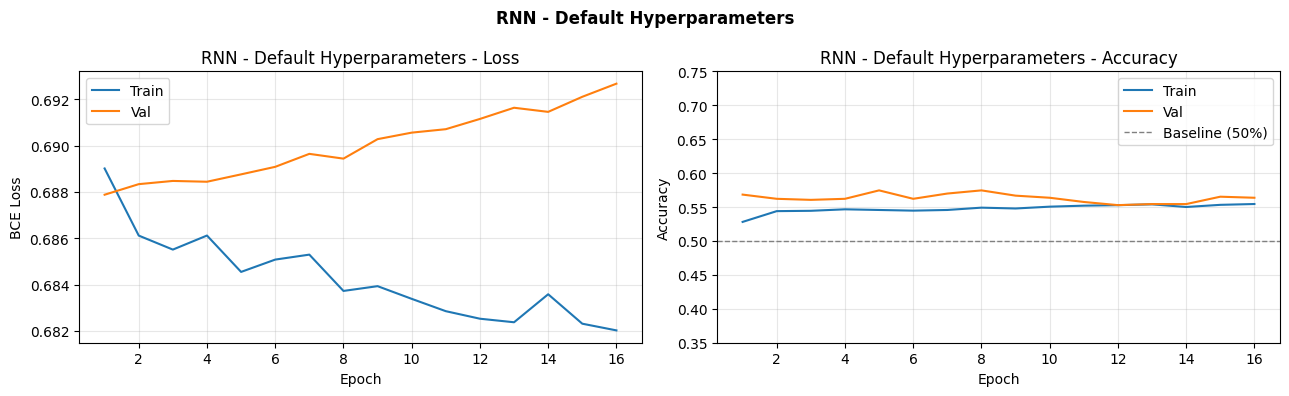

RNN Test Results
  Acc       : 0.5557
  F1        : 0.6877
  Precision : 0.5704
  Recall    : 0.8658

              precision    recall  f1-score   support

        Down       0.47      0.15      0.23       281
          Up       0.57      0.87      0.69       365

    accuracy                           0.56       646
   macro avg       0.52      0.51      0.46       646
weighted avg       0.53      0.56      0.49       646



In [ ]:
plot_history(rnn_hist, 'RNN - Default Hyperparameters', save='rnn_history.png')

_, rnn_te_p, rnn_te_l = run_epoch(rnn_model, test_loader, None, DEVICE)
rnn_te_m = compute_metrics(rnn_te_p, rnn_te_l)

print("RNN Test Results")
for k, v in rnn_te_m.items():
    print(f"  {k.capitalize():10s}: {v:.4f}")

print("\n" + classification_report(rnn_te_l, rnn_te_p,
      target_names=['Down','Up']))

These are promising first results for our initial RNN, they show accuracy above the guessing 0.5 (but just barely). They do show some form of learning over epochs and reduction in errors.

4.2 b. Train LSTM and plot results

In [ ]:
lstm_model = LSTM(INPUT_SIZE, hidden_size=64, num_layers=2, dropout=0.3).to(DEVICE)
n_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"LSTM trainable params: {n_lstm:,}\n")

t0 = time.time()
lstm_hist = train_model(lstm_model, train_loader, val_loader, lr=1e-3, weight_decay=1e-4, name='LSTM', patience=15)
print(f"\nLSTM wall-clock: {time.time()-t0:.1f}s")

LSTM trainable params: 52,289

[LSTM] Ep   1/60 | TrLoss=0.6882 TrAcc=0.5413 | VaLoss=0.6893 VaAcc=0.5497 VaF1=0.7094
[LSTM] Ep  10/60 | TrLoss=0.6850 TrAcc=0.5383 | VaLoss=0.6875 VaAcc=0.5606 VaF1=0.7133
[LSTM] Ep  20/60 | TrLoss=0.6819 TrAcc=0.5476 | VaLoss=0.6892 VaAcc=0.5606 VaF1=0.6894
[LSTM] Early stop at epoch 28.

LSTM wall-clock: 17.0s


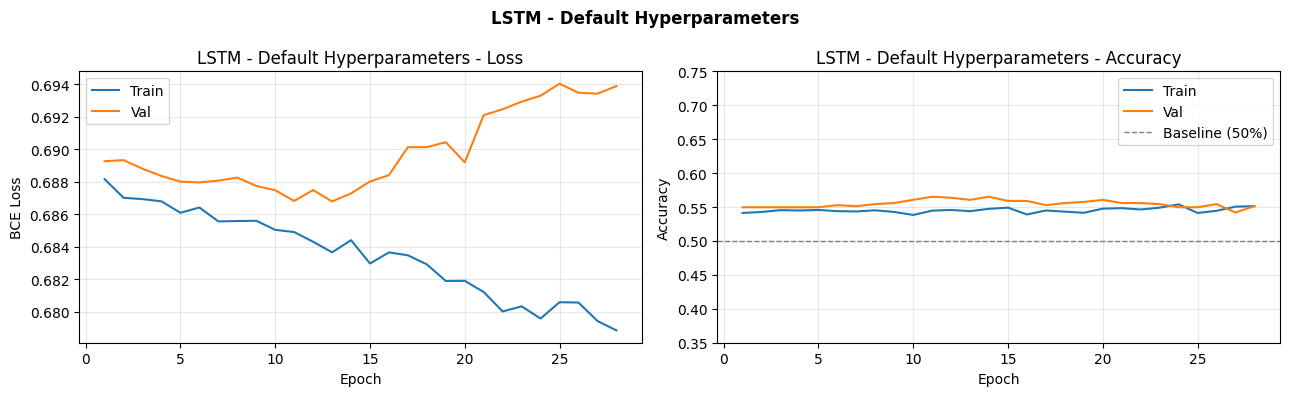

LSTM Test Results
  Acc       : 0.5573
  F1        : 0.6977
  Precision : 0.5680
  Recall    : 0.9041

              precision    recall  f1-score   support

        Down       0.46      0.11      0.17       281
          Up       0.57      0.90      0.70       365

    accuracy                           0.56       646
   macro avg       0.51      0.51      0.44       646
weighted avg       0.52      0.56      0.47       646



In [ ]:
plot_history(lstm_hist, 'LSTM - Default Hyperparameters', save='lstm_history.png')

_, lstm_te_p, lstm_te_l = run_epoch(lstm_model, test_loader, None, DEVICE)
lstm_te_m = compute_metrics(lstm_te_p, lstm_te_l)

print("LSTM Test Results")

for k, v in lstm_te_m.items():
    print(f"  {k.capitalize():10s}: {v:.4f}")

print("\n" + classification_report(lstm_te_l, lstm_te_p,
      target_names=['Down','Up']))

Again, very promising and is slightly better than guessing. Great baseline for the initial LSTM model.

4.2 c. Train transformer and show plots

In [ ]:
tf_model = Transformer(INPUT_SIZE, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.3).to(DEVICE)
n_tf = sum(p.numel() for p in tf_model.parameters() if p.requires_grad)
print(f"Transformer trainable params: {n_tf:,}\n")

t0 = time.time()
tf_hist = train_model(tf_model, train_loader, val_loader, lr=5e-4, weight_decay=1e-4, name='Transformer', patience=15)
print(f"\nTransformer wall-clock: {time.time()-t0:.1f}s")

Transformer trainable params: 67,585

[Transformer] Ep   1/60 | TrLoss=0.7392 TrAcc=0.5173 | VaLoss=0.6979 VaAcc=0.5543 VaF1=0.7110
[Transformer] Ep  10/60 | TrLoss=0.6887 TrAcc=0.5347 | VaLoss=0.6884 VaAcc=0.5683 VaF1=0.7092
[Transformer] Ep  20/60 | TrLoss=0.6861 TrAcc=0.5413 | VaLoss=0.6879 VaAcc=0.5621 VaF1=0.7134
[Transformer] Ep  30/60 | TrLoss=0.6838 TrAcc=0.5500 | VaLoss=0.6882 VaAcc=0.5621 VaF1=0.7122
[Transformer] Ep  40/60 | TrLoss=0.6844 TrAcc=0.5452 | VaLoss=0.6871 VaAcc=0.5668 VaF1=0.7127
[Transformer] Early stop at epoch 48.

Transformer wall-clock: 91.7s


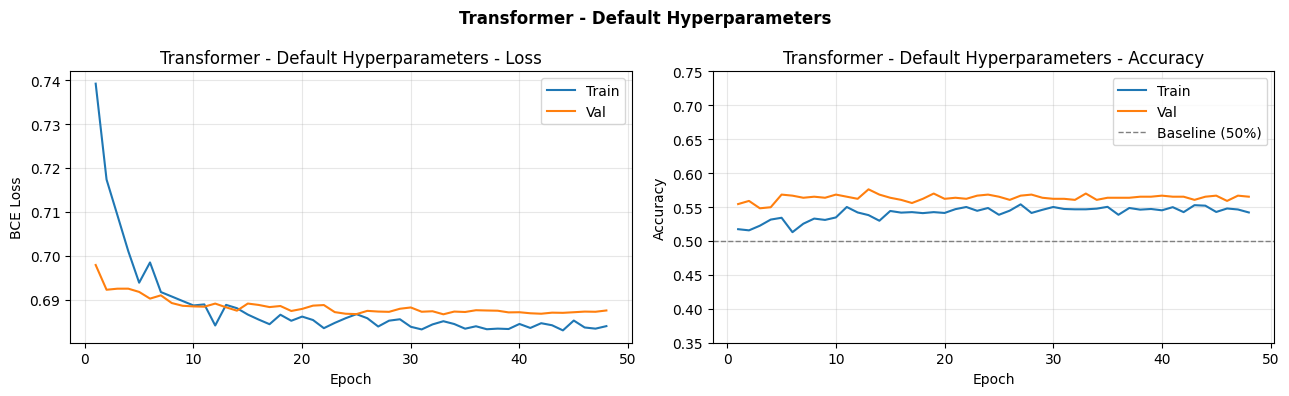

Transformer Test Results:

  Acc       : 0.5542
  F1        : 0.7000
  Precision : 0.5647
  Recall    : 0.9205

              precision    recall  f1-score   support

        Down       0.43      0.08      0.13       281
          Up       0.56      0.92      0.70       365

    accuracy                           0.55       646
   macro avg       0.50      0.50      0.42       646
weighted avg       0.51      0.55      0.45       646



In [ ]:
plot_history(tf_hist, 'Transformer - Default Hyperparameters', save='transformer_history.png')

_, tf_te_p, tf_te_l = run_epoch(tf_model, test_loader, None, DEVICE)
tf_te_m = compute_metrics(tf_te_p, tf_te_l)

print("Transformer Test Results:\n")
for k, v in tf_te_m.items():
    print(f"  {k.capitalize():10s}: {v:.4f}")

print("\n" + classification_report(tf_te_l, tf_te_p,
      target_names=['Down','Up']))

This noticably reports the worst accuracy among the three, still better than guessing though. It is rather bumpy in the metrics reported. Shows slight overfitting near the end of the epochs it trained on.

# 5. Optuna Hyperparameter Tuning across models:
After the initial model creation and training on uniform input and using the same functions, we can begin to improve and optimize these models via hyperparameter tuning. Using the best modern techniques, I use Bayesian Optimization through Optuna.

In [ ]:
# Optuna docs: https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html

# hidden_size search space capped at 128 - larger sizes showed minimal gain
# in preliminary runs and increased trial time significantly

OPTUNA_EPOCHS = 30
OPTUNA_TRIALS = 20

# Lightweight eval loop for Optuna - no scheduler, no early stopping
# trades some accuracy for ~3x faster trial iteration
# returning best val acc across epochs rather than final epoch

def _quick_train(model, optimizer, n_epochs):
    best_va = 0.0

    for _ in range(n_epochs):
        run_epoch(model, train_loader, optimizer, DEVICE)
        _, vp, vl = run_epoch(model, val_loader, None, DEVICE)
        va = accuracy_score(vl, vp)

        if va > best_va:
            best_va = va

    return best_va


def rnn_objective(trial):
    hs = trial.suggest_categorical('hidden_size', [32, 64, 128])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dp = trial.suggest_float('dropout', 0.1, 0.5)
    wd = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    m = RNN(INPUT_SIZE, hs, 1, dp).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)

    return -_quick_train(m, opt, OPTUNA_EPOCHS)


def lstm_objective(trial):
    hs = trial.suggest_categorical('hidden_size', [32, 64, 128])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dp = trial.suggest_float('dropout', 0.1, 0.5)
    wd = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    m = LSTM(INPUT_SIZE, hs, 2, dp).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)

    return -_quick_train(m, opt, OPTUNA_EPOCHS)


def tf_objective(trial):
    d_model = trial.suggest_categorical('d_model', [32, 64])
    nhead = trial.suggest_categorical('nhead', [2, 4])

    if d_model % nhead != 0:
        raise optuna.exceptions.TrialPruned()

    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    dp = trial.suggest_float('dropout', 0.1, 0.4)
    wd = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    m = Transformer(INPUT_SIZE, d_model, nhead, 2, 128, dp).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)

    return -_quick_train(m, opt, OPTUNA_EPOCHS)


print(f"Starting Optuna search - {OPTUNA_TRIALS} trials x 3 models "
      f"x {OPTUNA_EPOCHS} epochs each …")

sampler = TPESampler(seed=SEED)
rnn_study = optuna.create_study(direction='minimize', sampler=sampler)
lstm_study = optuna.create_study(direction='minimize', sampler=sampler)
tf_study = optuna.create_study(direction='minimize', sampler=sampler)

rnn_study.optimize(rnn_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
print("RNN done.")
lstm_study.optimize(lstm_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
print("LSTM done.")
tf_study.optimize(tf_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
print("Transformer done.")

print("\nBest Hyperparameters:\n\n")
for sname, study in [('RNN', rnn_study), ('LSTM', lstm_study), ('Transformer', tf_study)]:
    print(f"  {sname:12s} | Best Val Acc: {-study.best_value:.4f} | {study.best_params}")

Starting Optuna search - 20 trials x 3 models x 30 epochs each …
RNN done.
LSTM done.
Transformer done.

Best Hyperparameters:


  RNN          | Best Val Acc: 0.5947 | {'hidden_size': 64, 'lr': 0.0015751320499779737, 'dropout': 0.1624074561769746, 'weight_decay': 2.0511104188433963e-05}
  LSTM         | Best Val Acc: 0.5792 | {'hidden_size': 128, 'lr': 0.000844784802797997, 'dropout': 0.37963993964787135, 'weight_decay': 5.6462295535724625e-05}
  Transformer  | Best Val Acc: 0.5823 | {'d_model': 32, 'nhead': 4, 'lr': 0.00299562141521501, 'dropout': 0.27695901304645554, 'weight_decay': 0.0002514644486071284}


This has now found the most optimal parameters for these various models. We must be cautious while examining these before we retrain fully with these most optimal hyperparameters (this follows below).

Retrain with Best Hyperparameters

In [ ]:
# Transformer uses different constructor args than RNN/LSTM,
# so rebuild kwargs entirely rather than updating shared defaults

def retrain(model_cls, best_params, name, num_layers=1):
    if model_cls == Transformer:
        kwargs = dict(
            input_size = INPUT_SIZE,
            d_model = best_params.get('d_model', 64),
            nhead = best_params.get('nhead', 4),
            num_layers = 2,
            dim_feedforward = 128,
            dropout = best_params.get('dropout', 0.3),
        )

    else:
        kwargs = dict(
            input_size = INPUT_SIZE,
            hidden_size = best_params.get('hidden_size', 64),
            num_layers = num_layers,
            dropout = best_params.get('dropout', 0.3),
        )

    m = model_cls(**kwargs).to(DEVICE)
    h = train_model(m, train_loader, val_loader,
                    lr = best_params.get('lr', 1e-3),
                    weight_decay = best_params.get('weight_decay', 1e-4),
                    name = name, patience=15)
    return m, h


rnn_tuned, rnn_hist_t = retrain(RNN, rnn_study.best_params, 'RNN-Tuned',  num_layers=1)
lstm_tuned, lstm_hist_t = retrain(LSTM, lstm_study.best_params, 'LSTM-Tuned', num_layers=2)
tf_tuned, tf_hist_t = retrain(Transformer, tf_study.best_params, 'Transformer-Tuned')

print("\nAll tuned models ready.")

[RNN-Tuned] Ep   1/60 | TrLoss=0.6884 TrAcc=0.5361 | VaLoss=0.6902 VaAcc=0.5637 VaF1=0.6915
[RNN-Tuned] Ep  10/60 | TrLoss=0.6909 TrAcc=0.5276 | VaLoss=0.6908 VaAcc=0.5342 VaF1=0.6471
[RNN-Tuned] Ep  20/60 | TrLoss=0.6880 TrAcc=0.5420 | VaLoss=0.6915 VaAcc=0.5326 VaF1=0.6583
[RNN-Tuned] Ep  30/60 | TrLoss=0.6860 TrAcc=0.5405 | VaLoss=0.6847 VaAcc=0.5807 VaF1=0.7091
[RNN-Tuned] Ep  40/60 | TrLoss=0.6840 TrAcc=0.5488 | VaLoss=0.6839 VaAcc=0.5916 VaF1=0.7144
[RNN-Tuned] Ep  50/60 | TrLoss=0.6828 TrAcc=0.5554 | VaLoss=0.6847 VaAcc=0.5870 VaF1=0.7038
[RNN-Tuned] Ep  60/60 | TrLoss=0.6822 TrAcc=0.5562 | VaLoss=0.6846 VaAcc=0.5807 VaF1=0.6966
[LSTM-Tuned] Ep   1/60 | TrLoss=0.6886 TrAcc=0.5337 | VaLoss=0.6909 VaAcc=0.5497 VaF1=0.7094
[LSTM-Tuned] Ep  10/60 | TrLoss=0.6845 TrAcc=0.5476 | VaLoss=0.6867 VaAcc=0.5668 VaF1=0.7127
[LSTM-Tuned] Ep  20/60 | TrLoss=0.6812 TrAcc=0.5442 | VaLoss=0.6886 VaAcc=0.5637 VaF1=0.6888
[LSTM-Tuned] Early stop at epoch 24.
[Transformer-Tuned] Ep   1/60 | TrLoss=0

This trains these final models and now is prepared to report final results in the following section.

# 6. Comparison and Results (including charts and final metrics)
Evaluate All Tuned Models

In [ ]:
# Report results

MODELS = {
    'RNN': (rnn_tuned,  rnn_hist_t),
    'LSTM':(lstm_tuned, lstm_hist_t),
    'Transformer': (tf_tuned,   tf_hist_t),
}

results = {}
for mname, (model, _) in MODELS.items():
    _, tr_p, tr_l = run_epoch(model, train_loader, None, DEVICE)
    _, va_p, va_l = run_epoch(model, val_loader,   None, DEVICE)
    _, te_p, te_l = run_epoch(model, test_loader,  None, DEVICE)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    results[mname] = dict(
        train_acc = compute_metrics(tr_p, tr_l)['acc'],
        val_acc = compute_metrics(va_p, va_l)['acc'],
        **{f'test_{k}': v for k, v in compute_metrics(te_p, te_l).items()},
        n_params = n_params,
        te_preds = te_p,
        te_labels = te_l,
    )

    print(f"  {mname:12s} | TrainAcc={results[mname]['train_acc']:.4f} "
          f"| ValAcc = {results[mname]['val_acc']:.4f} "
          f"| TestAcc = {results[mname]['test_acc']:.4f} "
          f"| TestF1 = {results[mname]['test_f1']:.4f} "
          f"| Params = {n_params:,}")

  RNN          | TrainAcc=0.5559 | ValAcc = 0.5885 | TestAcc = 0.5449 | TestF1 = 0.6790 | Params = 4,801
  LSTM         | TrainAcc=0.5457 | ValAcc = 0.5714 | TestAcc = 0.5635 | TestF1 = 0.7105 | Params = 202,881
  Transformer  | TrainAcc=0.5420 | ValAcc = 0.5699 | TestAcc = 0.5557 | TestF1 = 0.7038 | Params = 25,729


This shows a comparitive analysis of the models.

Loss and Accuracy Plots

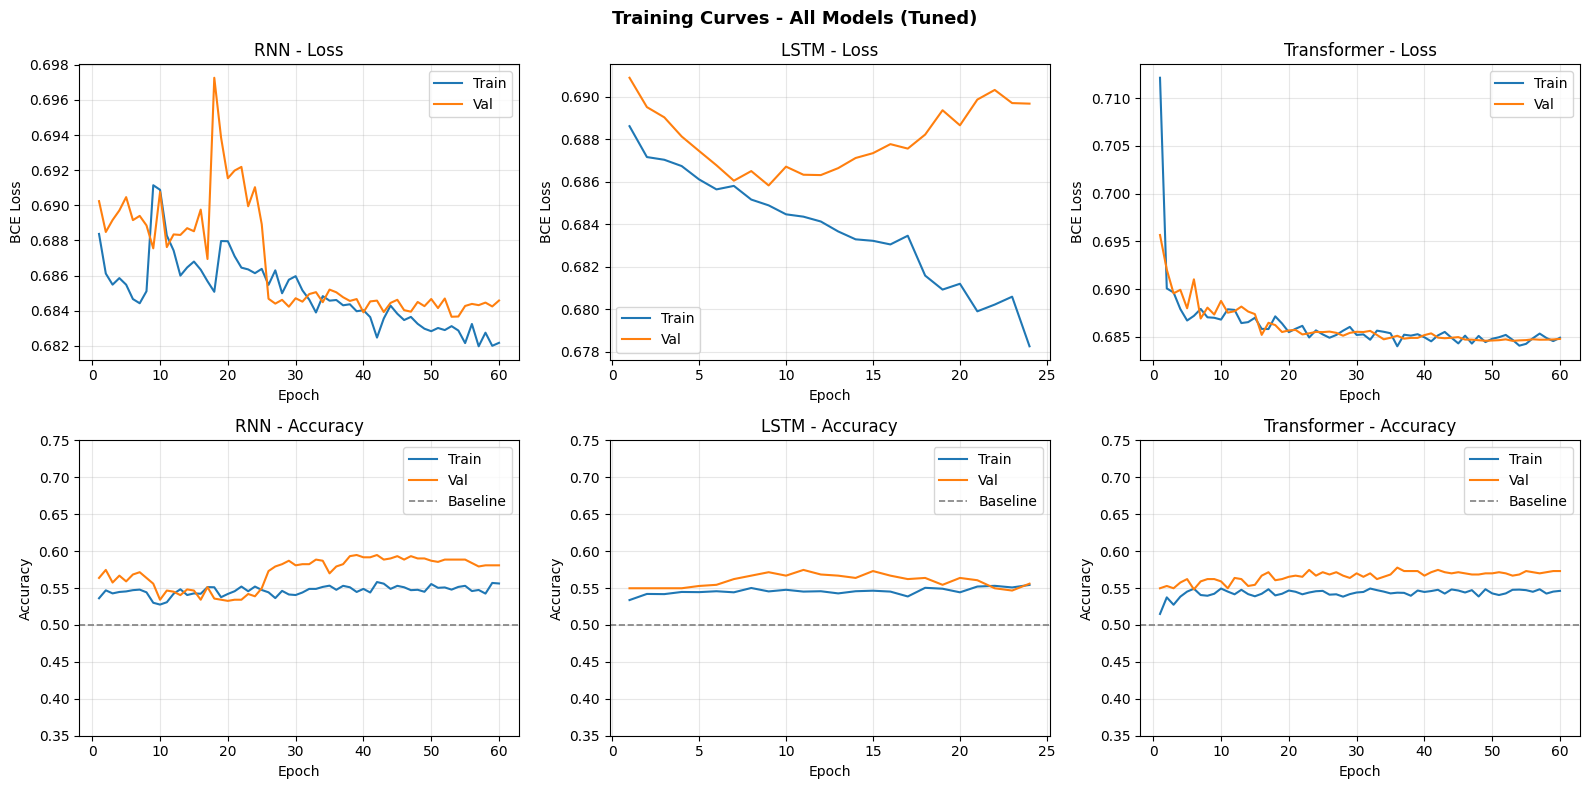

In [ ]:
# Loss and Accuracy Plots

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
c_tr, c_va = '#1f77b4', '#ff7f0e'

for col, (mname, (_, hist)) in enumerate(MODELS.items()):
    ep = range(1, len(hist['train_loss']) + 1)

    axes[0,col].plot(ep, hist['train_loss'], color=c_tr, lw=1.5, label='Train')
    axes[0,col].plot(ep, hist['val_loss'], color=c_va, lw=1.5, label='Val')
    axes[0,col].set(title=f'{mname} - Loss', xlabel='Epoch', ylabel='BCE Loss')
    axes[0,col].legend(); axes[0,col].grid(alpha=0.3)

    axes[1,col].plot(ep, hist['train_acc'], color=c_tr, lw=1.5, label='Train')
    axes[1,col].plot(ep, hist['val_acc'], color=c_va, lw=1.5, label='Val')
    axes[1,col].axhline(0.5, color='grey', ls='--', lw=1.2, label='Baseline')
    axes[1,col].set(title=f'{mname} - Accuracy', xlabel='Epoch',
                    ylabel='Accuracy', ylim=(0.35, 0.75))
    axes[1,col].legend(); axes[1,col].grid(alpha=0.3)

plt.suptitle('Training Curves - All Models (Tuned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('all_loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()

This demonstrates the various metrics across models in a side-by-side view for easy analysis. Most notably, the three models have very similar ending validation accuracy reports. All coming in approximately at the same accuracy and only varying in exact smoothness of accuracy trends and gap between training and validation accuracy. The TF and RNN report similar metrics (the TF being bumpier), while the LSTM eventually clearly overfits.

The loss graphs are far more notable and show how much each model improves on the loss. The TF and RNN have fairly similar graphs while the LSTM shows a sharp decrease in initial training loss, while later then maintaining a close training and validation loss difference. The other two models gradually widen this loss gap, though, although the RNN has a flatlining validation loss and spike in training loss near the end. The LSTM loss graph does report troubling metrics with the validation loss being dramatically higher as time goes on.

Summary Comparison Table

In [ ]:
# Nice looking side-by-side table.

rows = []
for mname, r in results.items():
    rows.append({
        'Model': mname,
        'Train Acc': f"{r['train_acc']:.4f}",
        'Val Acc': f"{r['val_acc']:.4f}",
        'Test Acc': f"{r['test_acc']:.4f}",
        'Test F1': f"{r['test_f1']:.4f}",
        'Test Precision': f"{r['test_precision']:.4f}",
        'Test Recall': f"{r['test_recall']:.4f}",
        'Parameters': f"{r['n_params']:,}",
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print("\n" + "="*75)
print("FINAL MODEL COMPARISON TABLE")
print("-"*75)
print(summary_df.to_string())
print("-"*75)
print("\nBaseline (random): 50.00%")
summary_df


FINAL MODEL COMPARISON TABLE
---------------------------------------------------------------------------
            Train Acc Val Acc Test Acc Test F1 Test Precision Test Recall Parameters
Model                                                                               
RNN            0.5559  0.5885   0.5449  0.6790         0.5644      0.8521      4,801
LSTM           0.5457  0.5714   0.5635  0.7105         0.5681      0.9479    202,881
Transformer    0.5420  0.5699   0.5557  0.7038         0.5646      0.9342     25,729
---------------------------------------------------------------------------

Baseline (random): 50.00%


,Train Acc,Val Acc,Test Acc,Test F1,Test Precision,Test Recall,Parameters
Model,,,,,,,
RNN,0.5559,0.5885,0.5449,0.6790,0.5644,0.8521,"4,801"
LSTM,0.5457,0.5714,0.5635,0.7105,0.5681,0.9479,"202,881"
Transformer,0.5420,0.5699,0.5557,0.7038,0.5646,0.9342,"25,729"


This reports a easy to read comparison of metrics.

Bar Charts

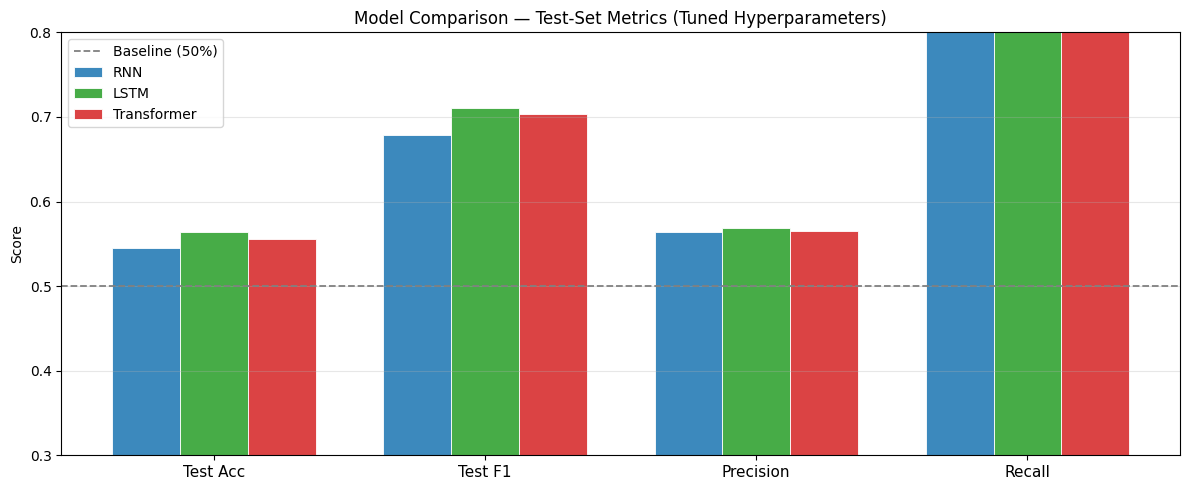

In [ ]:
# Bar charts!!

metric_keys = ['test_acc',  'test_f1', 'test_precision', 'test_recall']
metric_labels = ['Test Acc', 'Test F1', 'Precision', 'Recall']
model_names = list(results.keys())
colours = ['#1f77b4', '#2ca02c', '#d62728']

x = np.arange(len(metric_keys))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

for i, (mname, colour) in enumerate(zip(model_names, colours)):
    vals = [results[mname][k] for k in metric_keys]
    ax.bar(x + i*w, vals, width=w, label=mname, color=colour,
           alpha=0.87, edgecolor='white', lw=0.7)

ax.axhline(0.5, color='grey', ls='--', lw=1.3, label='Baseline (50%)')
ax.set_xticks(x + w); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set(ylabel='Score', ylim=(0.30, 0.80),
       title='Model Comparison — Test-Set Metrics (Tuned Hyperparameters)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=120, bbox_inches='tight')
plt.show()

These act as a further visualization as a bar chart for out models metrics.

Confusion Matrices

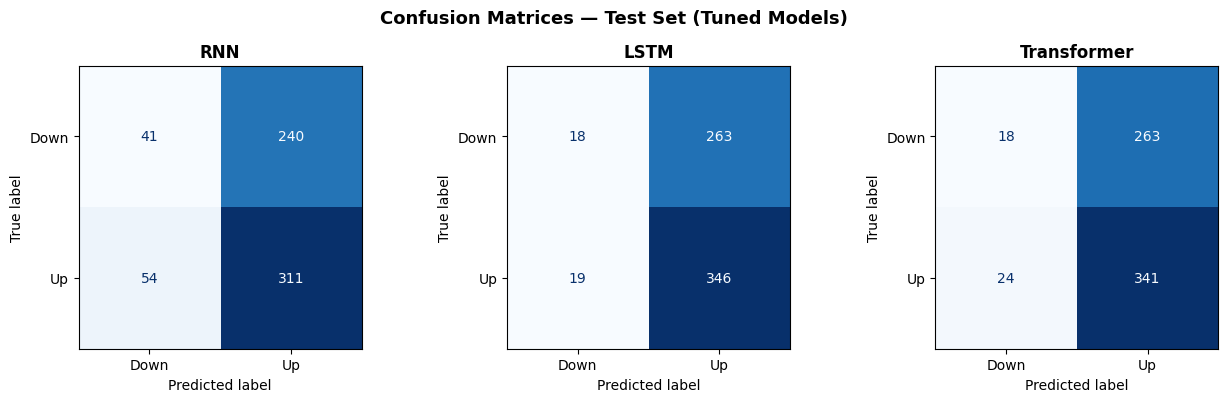

In [ ]:
# Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (mname, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        r['te_labels'], r['te_preds'],
        display_labels=['Down','Up'],
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(mname, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set (Tuned Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

Again, we have confusion matrices showing a distribution that is very similar across models.

# Threshold Tuning

Val set threshold tuning results:

RNN -- best threshold: 0.520 | Val Macro F1: 0.5460 | Val Acc: 0.5839 | Precision: 0.5903 | Recall: 0.7938
LSTM -- best threshold: 0.530 | Val Macro F1: 0.5418 | Val Acc: 0.5575 | Precision: 0.5844 | Recall: 0.6751
Transformer -- best threshold: 0.530 | Val Macro F1: 0.5381 | Val Acc: 0.5699 | Precision: 0.5839 | Recall: 0.7571
  RNN -- Validation Threshold Sweep

   Threshold    Macro F1    Accuracy   Precision      Recall

        0.30      0.3547      0.5497      0.5497      1.0000
        0.31      0.3547      0.5497      0.5497      1.0000
        0.32      0.3547      0.5497      0.5497      1.0000
        0.33      0.3547      0.5497      0.5497      1.0000
        0.34      0.3547      0.5497      0.5497      1.0000
        0.35      0.3547      0.5497      0.5497      1.0000
        0.36      0.3547      0.5497      0.5497      1.0000
        0.37      0.3547      0.5497      0.5497      1.0000
        0.38      0.3547      0.5497      0.5497

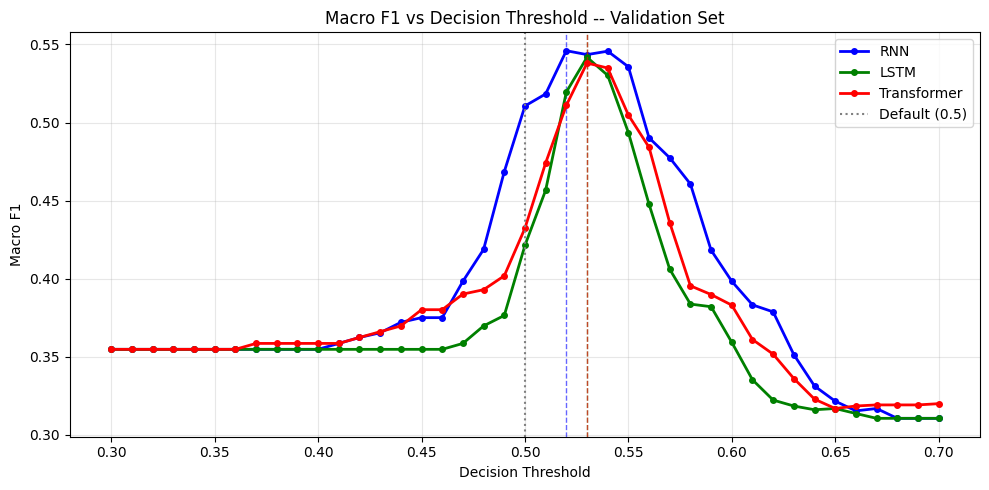

TEST SET: Default (0.5) vs Best Validation Threshold

  Model          Threshold    Macro F1    Accuracy   Recall (Down)

  RNN           0.50 (base)      0.4486      0.5449          0.1459
                      0.52             0.4809      0.5217          0.2776
  -----------------------------------------------------------------
  LSTM          0.50 (base)      0.4118      0.5635          0.0641
                      0.53             0.4881      0.5046          0.3737
  -----------------------------------------------------------------
  Transformer   0.50 (base)      0.4076      0.5557          0.0641
                      0.53             0.4817      0.5093          0.3203
  -----------------------------------------------------------------


In [ ]:
# Inference-Side threshold Tuning and Probability Distributions
# Goal is to find the optimal threshold that maximizes Macro F1 on validation set and apply on test set to measure real-world gain.

import matplotlib.ticker as mticker

THRESHOLDS = np.arange(0.3, 0.71, 0.01)

# Collect raw sigmoid probs and labels for a loader. Returns as an array formatted like (N, ) for both probs and labels.

def get_probs(model, loader, device=DEVICE):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(DEVICE)
            logits = model(X_b).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy())

    return np.array(all_probs), np.array(all_labels)

# With given probs and labels, evaluate each threshold.

def threshold_sweep(probs, labels, thresholds):
    rows = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        rows.append({
            'threshold': round(float(t), 3),
            'macro_f1':  round(f1_score(labels, preds, average='macro',  zero_division=0), 4),
            'acc':       round(accuracy_score(labels, preds), 4),
            'precision': round(precision_score(labels, preds, zero_division=0), 4),
            'recall':    round(recall_score(labels, preds, zero_division=0), 4),
        })
    return rows

# Get validation probs and labels for each model, find best threshold, and apply to test set.

val_probs = {}
val_labels_ref = None


for mname, (model, _) in MODELS.items():
    probs, labels = get_probs(model, val_loader, DEVICE)
    val_probs[mname] = probs

    if val_labels_ref is None:
        val_labels_ref = labels

print("Val set threshold tuning results:\n")

# Find best threshold for each model based on validation Macro F1

sweep_results = {}
best_thresholds = {}

for mname, probs in val_probs.items():
    rows = threshold_sweep(probs, val_labels_ref, THRESHOLDS)
    sweep_results[mname] = rows
    best_row = max(rows, key=lambda x: x['macro_f1'])
    best_thresholds[mname] = best_row['threshold']
    print(f"{mname} -- best threshold: {best_row['threshold']:.3f} | Val Macro F1: {best_row['macro_f1']:.4f} | Val Acc: {best_row['acc']:.4f} | Precision: {best_row['precision']:.4f} | Recall: {best_row['recall']:.4f}")

# Print full sweep results for one model as example
for mname, rows in sweep_results.items():
    print(f"  {mname} -- Validation Threshold Sweep\n")
    print(f"  {'Threshold':>10}  {'Macro F1':>10}  {'Accuracy':>10}  {'Precision':>10}  {'Recall':>10}\n")
    for r in rows:
        marker = '  <-- best' if r['threshold'] == best_thresholds[mname] else ''
        print(f"  {r['threshold']:>10.2f}  {r['macro_f1']:>10.4f}  {r['acc']:>10.4f}  {r['precision']:>10.4f}  {r['recall']:>10.4f}{marker}")

# Plot Macro F1 vs threshold for all three models
fig, ax = plt.subplots(figsize=(10, 5))
colours = {'RNN': 'blue', 'LSTM': 'green', 'Transformer': 'red'}

for mname, rows in sweep_results.items():
    xs = [r['threshold'] for r in rows]
    ys = [r['macro_f1'] for r in rows]
    ax.plot(xs, ys, label=mname, color=colours[mname], lw=2.0, marker='o', ms=4)
    ax.axvline(best_thresholds[mname], color=colours[mname], ls='--', lw=1.0, alpha=0.6)

ax.axvline(0.5, color='grey', ls=':', lw=1.5, label='Default (0.5)')
ax.set(xlabel='Decision Threshold', ylabel='Macro F1',
       title='Macro F1 vs Decision Threshold -- Validation Set',
       xlim=(0.28, 0.72))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

# Apply the best validation threshold to the test set and compare against 0.5 baseline
test_probs = {}
for mname, (model, _) in MODELS.items():
    probs, te_labels = get_probs(model, test_loader)
    test_probs[mname] = (probs, te_labels)

print("TEST SET: Default (0.5) vs Best Validation Threshold\n")
print(f"  {'Model':12s}  {'Threshold':>10}  {'Macro F1':>10}  {'Accuracy':>10}  {'Recall (Down)':>14}\n")

for mname in MODELS:
    probs, te_l = test_probs[mname]

    # default
    preds_05 = (probs >= 0.5).astype(int)
    f1_05 = f1_score(te_l, preds_05, average='macro', zero_division=0)
    acc_05 = accuracy_score(te_l, preds_05)
    rec_down_05 = recall_score(te_l, preds_05, pos_label=0, zero_division=0)

    # tuned
    best_t = best_thresholds[mname]
    preds_t = (probs >= best_t).astype(int)
    f1_t = f1_score(te_l, preds_t, average='macro', zero_division=0)
    acc_t = accuracy_score(te_l, preds_t)
    rec_down_t = recall_score(te_l, preds_t, pos_label=0, zero_division=0)

    print(f"  {mname:12s}  {'0.50 (base)':>10}  {f1_05:>10.4f}  {acc_05:>10.4f}  {rec_down_05:>14.4f}")
    print(f"  {' ':12s}  {best_t:>10.2f}         {f1_t:>10.4f}  {acc_t:>10.4f}  {rec_down_t:>14.4f}")
    print(f"  {'-'*65}")

# 8. Final Analysis/Discussion:

Starting from the beginning of this pipeline, we must notice the importance of the feature extraction and actual input for these models. I previously looked at using just binary input of prior day gain (1 being up, 0 being down). This was nowhere near as good. So, feature extraction and total work put into preprocessing is incredibly important for this particular problem. Moving on from this, we notice closely from the beginning these three models perform extremely similarly. Moreover, as we look at the final results, it is clear that after all models are fully tuned (hyperparameter wise) and retrained, the tuned Transformer comes in third place overall across the board. Likewise, the RNN then follows this with a consistent second across the board. Finally, the LSTM shows it barely outperforms all other models. The notably thing, with this entire pipeline though, is that these differences are extremely slight. However, we must remember the problem at hand. We are attempting a very difficult task, and attempting to be barely better than guessing randomly. As stated previously, current SOTA methodologies perform in the low-mid 60% range for testing accuracy. This reflects the complex nature of this task, and notably the importance and signficance of these slight differences. Overall, these differences compliment the nature of these model types. RNNs generally have pitfalls in remembering long-term representations of meaning, but work well with simple data. Conversely, LSTMs generally outperform them utilizing a longer-term memory of data. And overall excel when using temporal data. Finally, the attention mechanism in Transformers give it benefits in performance in numerous tasks across the board, but still can have pitfalls against LSTMs with temporal information. Similarly, this is reflected throughout this notebook. It is just such a 'close' race due to the task at hand. However, these do perfectly agree with and represent what I expected and forsaw happening. Another notable thing is viewed in our confusion matrices. This is incredibly problematic. It is very good at determining when an 'Up' will follow, but this led it to almost always just guess 'Up' across the board. Overwhelmingly, this is the problem at hand for these models.

# External Sources AI Use Statement

I used lots of outside documentation which was all cited. Some were tutorials, some were straight from documenation sites. Particularly, the Geeksforgeeks tutorials, Optunas documentation, Matplotlibs documentation, and yfinances documents were incredibly helpful.

Further, I utilized AI tools to assist creating the sliding window mechanism and some backend mathematics for the feature engineering. Besides this, it wasn't used much.